<a href="https://colab.research.google.com/github/ekuelkpodar/Researchers/blob/main/Physicists.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Load the dataset
df = pd.read_csv('/content/physicists.csv')

# Display basic information and first few rows
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12256 entries, 0 to 12255
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   explore href                 12256 non-null  object
 1   item-link                    12256 non-null  object
 2   tablescraper-selected-row    12256 non-null  object
 3   tablescraper-selected-row 2  11160 non-null  object
 4   item-link 2                  12256 non-null  object
 5   item-link href 2             12256 non-null  object
 6   tablescraper-selected-row 3  6892 non-null   object
dtypes: object(7)
memory usage: 670.4+ KB
None


,explore href,item-link,tablescraper-selected-row,tablescraper-selected-row 2,item-link 2,item-link href 2,tablescraper-selected-row 3
0,http://www.wikidata.org/entity/Q105761,wd:Q105761,Q105761,6 February 1941,<https://en.wikipedia.org/wiki/Klaus_Buchner>,https://en.wikipedia.org/wiki/Klaus_Buchner,NaN
1,http://www.wikidata.org/entity/Q109370,wd:Q109370,Q109370,25 October 1931,<https://en.wikipedia.org/wiki/Klaus_Hasselmann>,https://en.wikipedia.org/wiki/Klaus_Hasselmann,NaN
2,http://www.wikidata.org/entity/Q110406274,wd:Q110406274,Q110406274,1 January 1964,<https://en.wikipedia.org/wiki/Ma_Yuqiang>,https://en.wikipedia.org/wiki/Ma_Yuqiang,NaN
3,http://www.wikidata.org/entity/Q110719,wd:Q110719,Q110719,16 September 1943,<https://en.wikipedia.org/wiki/Oskar_Lafontaine>,https://en.wikipedia.org/wiki/Oskar_Lafontaine,NaN
4,http://www.wikidata.org/entity/Q115741,wd:Q115741,Q115741,15 December 1802,<https://en.wikipedia.org/wiki/Jean-Daniel_Col...,https://en.wikipedia.org/wiki/Jean-Daniel_Coll...,30 June 1893


### Exploratory Data Analysis
Let's check for missing values and the distribution of categorical data such as 'Nationality' or 'Fields' if available.

In [ ]:
# Summary statistics for categorical columns
for col in df.select_dtypes(include=['object']).columns:
    print(f'\nTop 10 {col}:')
    print(df[col].value_counts().head(10))

# Check for missing values
display(df.isnull().sum())


Top 10 explore href:
explore href
http://www.wikidata.org/entity/Q686541       4
http://www.wikidata.org/entity/Q3052333      4
http://www.wikidata.org/entity/Q5093646      4
http://www.wikidata.org/entity/Q18530845     4
http://www.wikidata.org/entity/Q1268728      4
http://www.wikidata.org/entity/Q72198        4
http://www.wikidata.org/entity/Q16403551     4
http://www.wikidata.org/entity/Q116626581    4
http://www.wikidata.org/entity/Q4493568      4
http://www.wikidata.org/entity/Q10972121     4
Name: count, dtype: int64

Top 10 item-link:
item-link
wd:Q686541       4
wd:Q3052333      4
wd:Q5093646      4
wd:Q18530845     4
wd:Q1268728      4
wd:Q72198        4
wd:Q16403551     4
wd:Q116626581    4
wd:Q4493568      4
wd:Q10972121     4
Name: count, dtype: int64

Top 10 tablescraper-selected-row:
tablescraper-selected-row
William Watson                 6
Friedrich Christian Günther    4
Mitchell A. Wilson             4
Michael Raupach                4
Theodoric of Freiberg          

,0
explore href,0
item-link,0
tablescraper-selected-row,0
tablescraper-selected-row 2,1096
item-link 2,0
item-link href 2,0
tablescraper-selected-row 3,5364


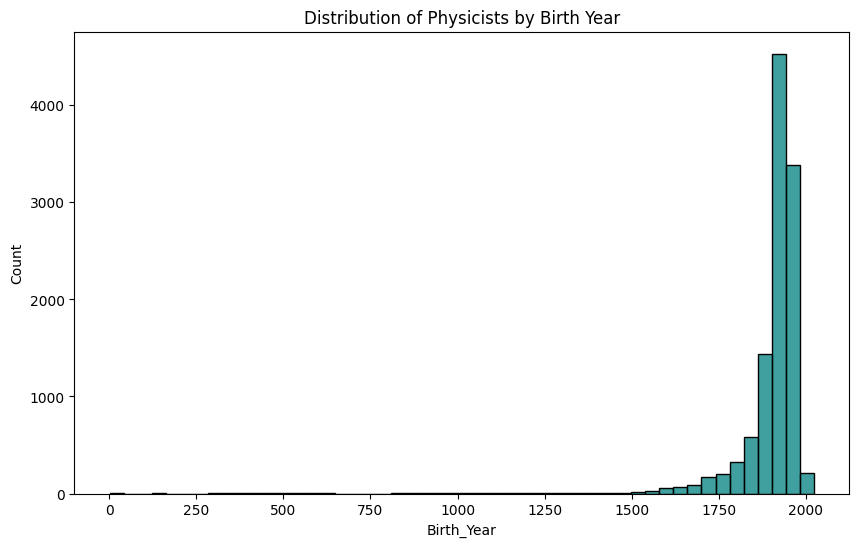

In [ ]:
import re

# Rename columns to human-readable names
df_cleaned = df.rename(columns={
    'tablescraper-selected-row': 'Name',
    'tablescraper-selected-row 2': 'Birth_Date',
    'tablescraper-selected-row 3': 'Death_Date',
    'item-link href 2': 'Wiki_URL'
})

def extract_year(date_str):
    if pd.isna(date_str):
        return None
    match = re.search(r'\d{4}', str(date_str))
    return int(match.group()) if match else None

df_cleaned['Birth_Year'] = df_cleaned['Birth_Date'].apply(extract_year)
df_cleaned['Death_Year'] = df_cleaned['Death_Date'].apply(extract_year)

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Birth_Year'].dropna(), bins=50, color='teal')
plt.title('Distribution of Physicists by Birth Year')
plt.show()

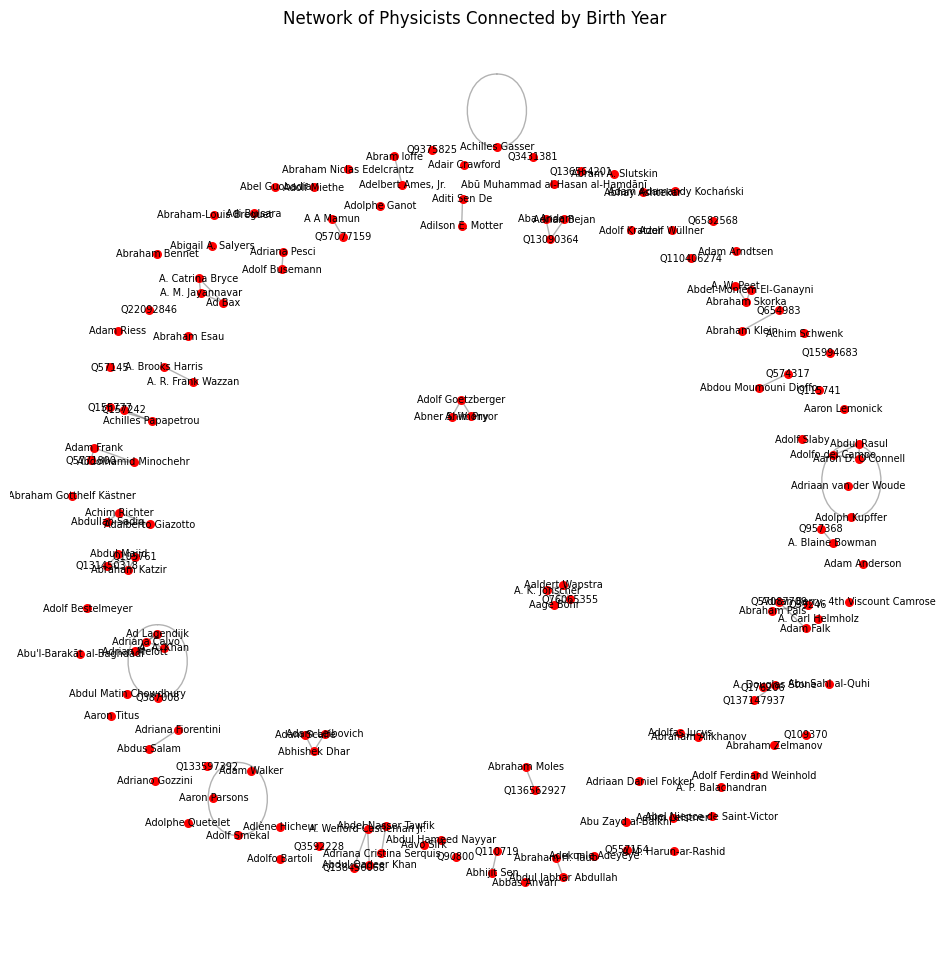

In [ ]:
# Create a network showing physicists born in the same year (sample for visibility)
G = nx.Graph()
subset = df_cleaned.dropna(subset=['Birth_Year']).head(150)

for _, row in subset.iterrows():
    G.add_node(row['Name'])

# Connect physicists born in the same year
year_groups = subset.groupby('Birth_Year')['Name'].apply(list)
for year, names in year_groups.items():
    if len(names) > 1:
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                G.add_edge(names[i], names[j])

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.15)
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='red')
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=7)
plt.title('Network of Physicists Connected by Birth Year')
plt.axis('off')
plt.show()

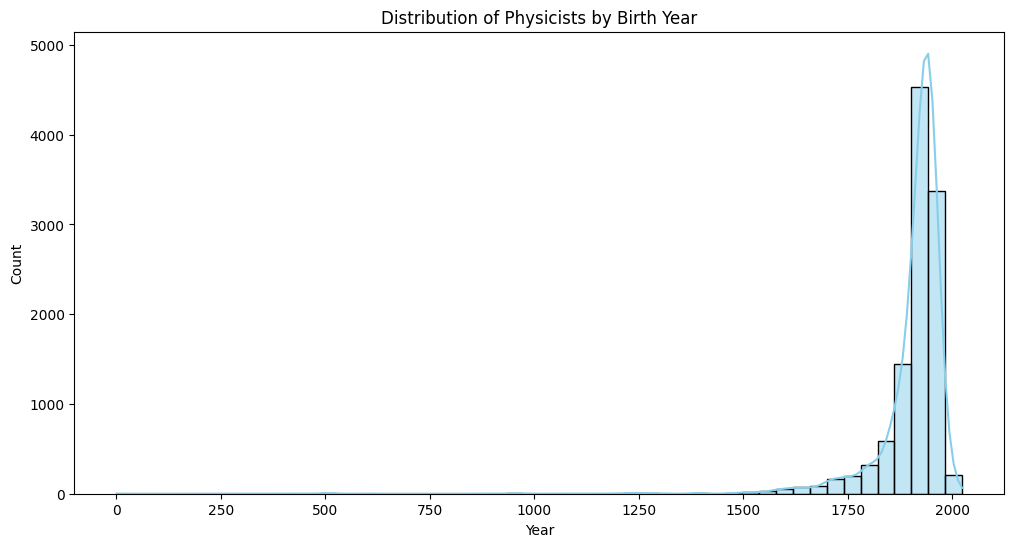

In [ ]:
# Rename columns for clarity
df_cleaned = df.rename(columns={
    'tablescraper-selected-row': 'Name',
    'tablescraper-selected-row 2': 'Birth_Date',
    'tablescraper-selected-row 3': 'Death_Date',
    'item-link href 2': 'Wiki_URL'
})

# Helper function to extract year
def extract_year(date_str):
    if pd.isna(date_str):
        return None
    try:
        # Simple extraction of 4-digit year
        import re
        match = re.search(r'\d{4}', str(date_str))
        return int(match.group()) if match else None
    except:
        return None

df_cleaned['Birth_Year'] = df_cleaned['Birth_Date'].apply(extract_year)
df_cleaned['Death_Year'] = df_cleaned['Death_Date'].apply(extract_year)

# Plotting distribution of Birth Years
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned['Birth_Year'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribution of Physicists by Birth Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

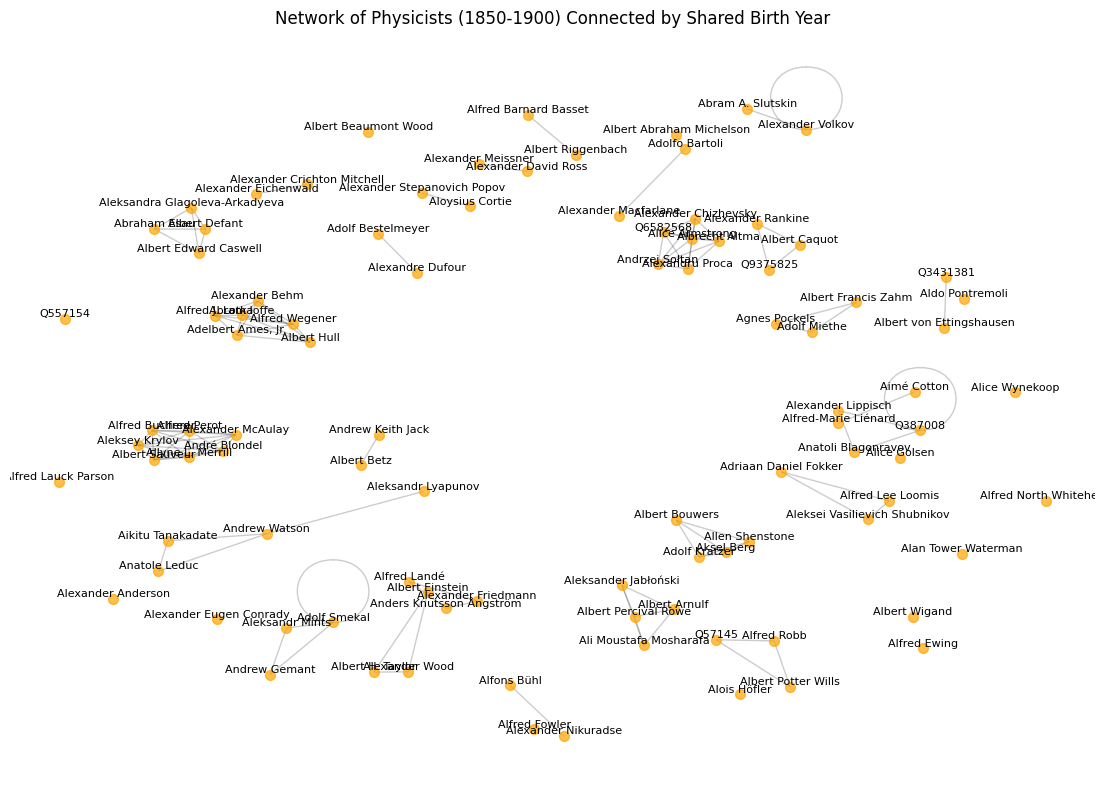

In [ ]:
# Network Analysis: Create a network of physicists born in the same decade
# To keep the graph readable, we'll sample a subset or focus on a specific era
G = nx.Graph()

# Focusing on physicists born between 1850 and 1900 for a clear network
subset = df_cleaned[(df_cleaned['Birth_Year'] >= 1850) & (df_cleaned['Birth_Year'] <= 1900)].head(100)

for i, row in subset.iterrows():
    G.add_node(row['Name'], year=row['Birth_Year'])

# Connect physicists born in the same year within this subset
for i, row1 in subset.iterrows():
    for j, row2 in subset.iterrows():
        if i < j and row1['Birth_Year'] == row2['Birth_Year']:
            G.add_edge(row1['Name'], row2['Name'])

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.15, iterations=20)
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='orange', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.2)
nx.draw_networkx_labels(G, pos, font_size=8, verticalalignment='bottom')
plt.title('Network of Physicists (1850-1900) Connected by Shared Birth Year')
plt.axis('off')
plt.show()

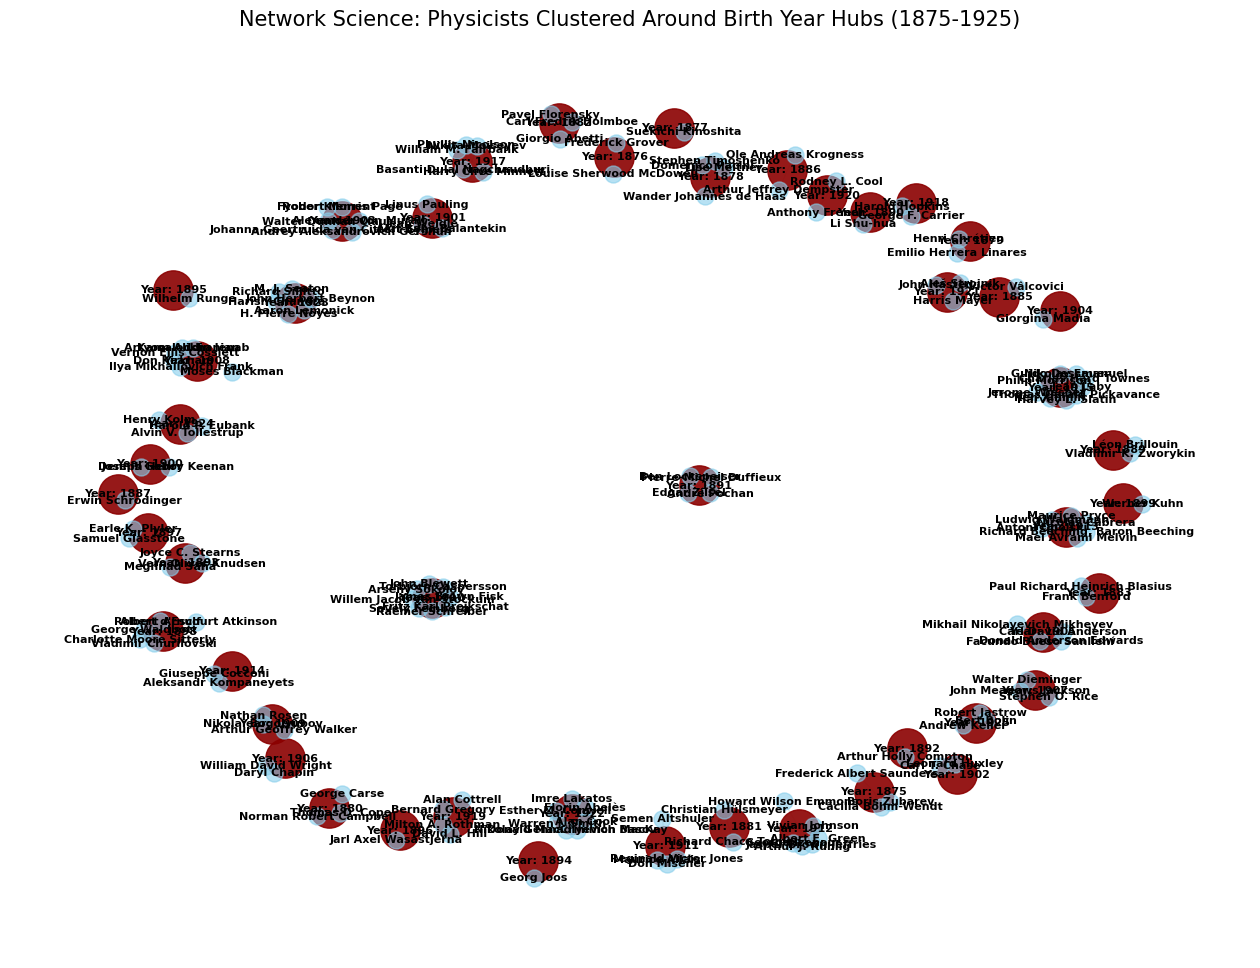

In [ ]:
# Identify the 'Golden Age' cluster (1875-1925)
golden_age = df_cleaned[(df_cleaned['Birth_Year'] >= 1875) & (df_cleaned['Birth_Year'] <= 1925)]

# Create a hub-and-spoke network for clearer clustering
G_hub = nx.Graph()

# Sample 150 physicists for a cleaner visual
subset_cluster = golden_age.sample(150, random_state=42)

for idx, row in subset_cluster.iterrows():
    year_node = f"Year: {int(row['Birth_Year'])}"
    # Add the physicist node
    G_hub.add_node(row['Name'], type='physicist')
    # Add the year node as a hub
    G_hub.add_node(year_node, type='year')
    # Connect physicist to their birth year
    G_hub.add_edge(row['Name'], year_node)

# Prepare visualization
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_hub, k=0.12, iterations=100)

# Separate nodes by type
phys_nodes = [n for n, v in G_hub.nodes(data=True) if v.get('type') == 'physicist']
year_nodes = [n for n, v in G_hub.nodes(data=True) if v.get('type') == 'year']

# Draw hubs (Years)
nx.draw_networkx_nodes(G_hub, pos, nodelist=year_nodes,
                       node_color='darkred', node_size=800, alpha=0.9)
# Draw spokes (Physicists)
nx.draw_networkx_nodes(G_hub, pos, nodelist=phys_nodes,
                       node_color='skyblue', node_size=150, alpha=0.6)

# Draw edges and labels
nx.draw_networkx_edges(G_hub, pos, alpha=0.2, edge_color='gray')
nx.draw_networkx_labels(G_hub, pos, font_size=8, font_weight='bold')

plt.title('Network Science: Physicists Clustered Around Birth Year Hubs (1875-1925)', fontsize=15)
plt.axis('off')
plt.show()

### Network Insight
In this graph, each distinct 'cluster' represents a specific birth year. Large, dense clusters (cliques) indicate years that produced an unusually high number of physicists, representing high-density periods of scientific development. The distance between clusters reflects the 'spring' layout's attempt to organize these cohorts in a social space.

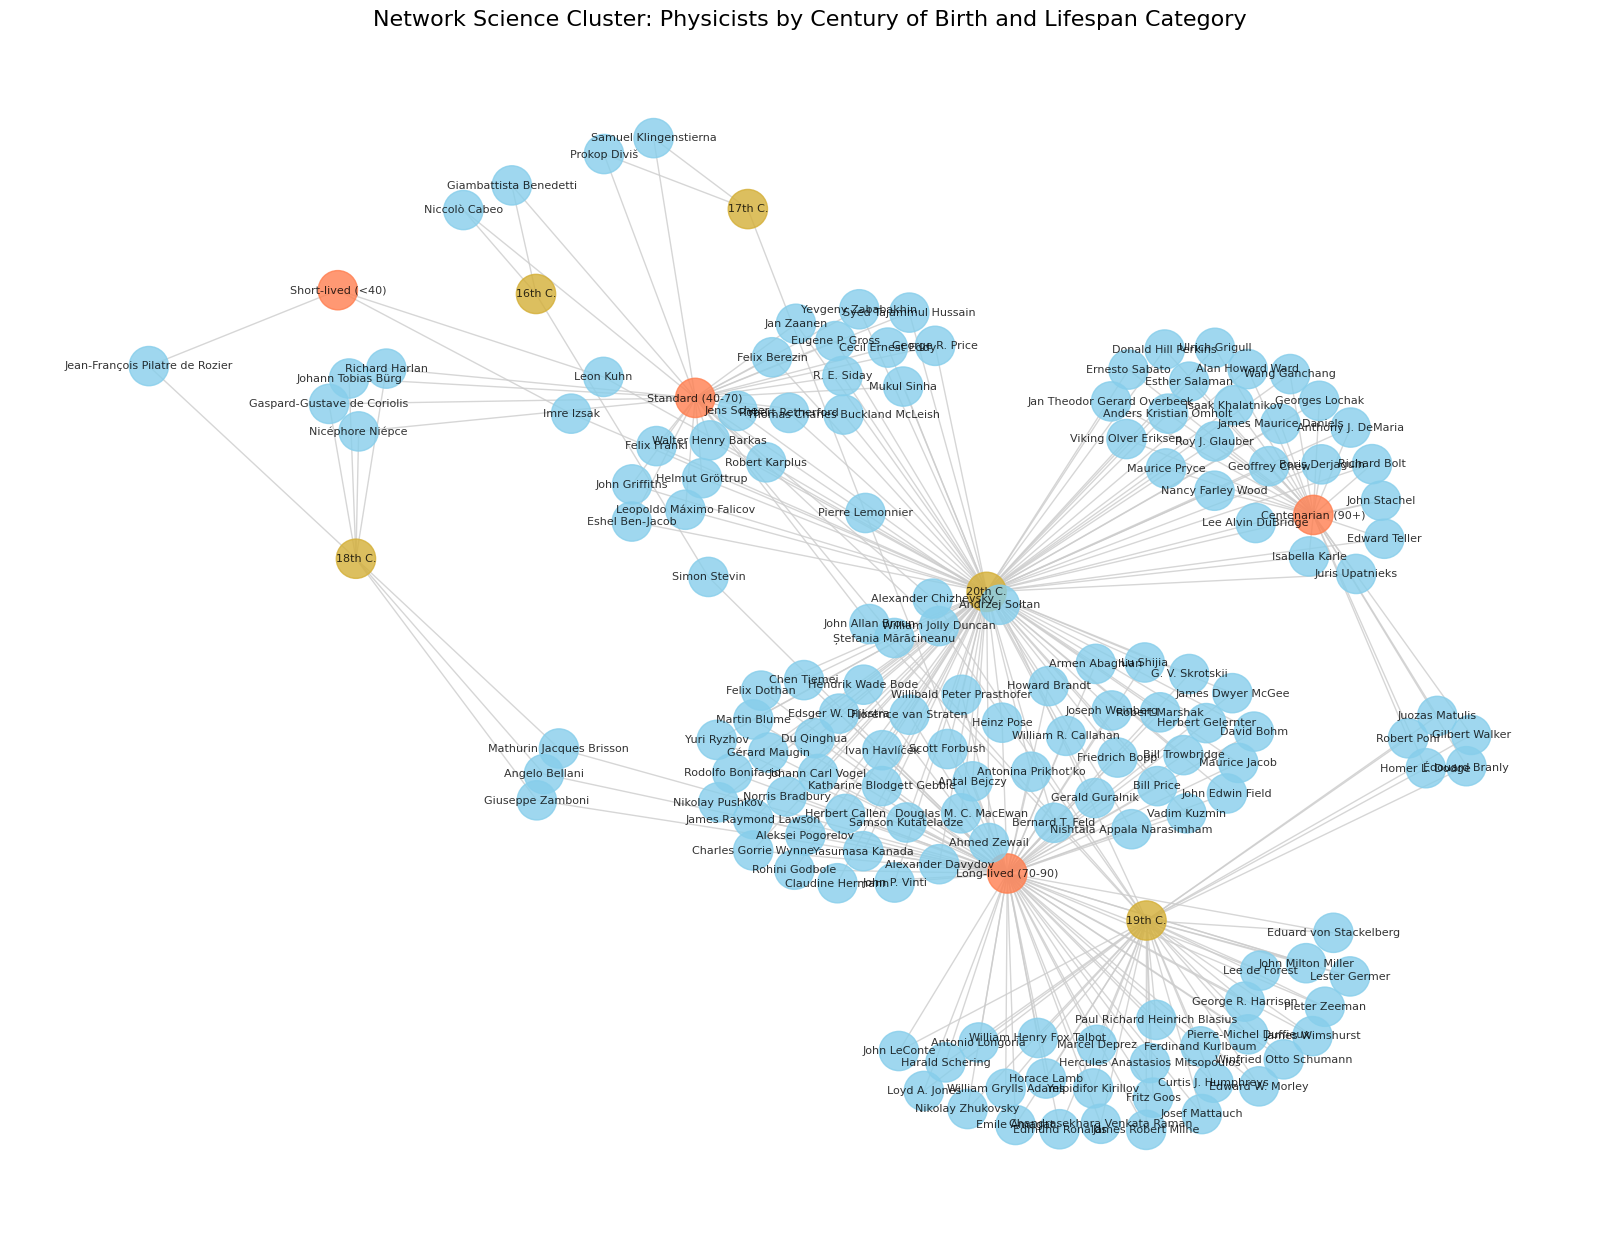

In [ ]:
# Calculate lifespan and century
df_cleaned['Lifespan'] = df_cleaned['Death_Year'] - df_cleaned['Birth_Year']
df_cleaned['Century'] = (df_cleaned['Birth_Year'] // 100 + 1).fillna(0).astype(int)

# Filter for valid data and categorize lifespan
valid_life = df_cleaned.dropna(subset=['Lifespan', 'Birth_Year'])
valid_life = valid_life[(valid_life['Lifespan'] > 0) & (valid_life['Lifespan'] < 115)]

def age_group(age):
    if age < 40: return 'Short-lived (<40)'
    if age < 70: return 'Standard (40-70)'
    if age < 90: return 'Long-lived (70-90)'
    return 'Centenarian (90+)'

valid_life['Age_Group'] = valid_life['Lifespan'].apply(age_group)

# Create the Network
G_life = nx.Graph()
sample_size = 150
subset_life = valid_life.sample(min(len(valid_life), sample_size), random_state=42)

for _, row in subset_life.iterrows():
    phys_node = row['Name']
    century_node = f"{int(row['Century'])}th C."
    age_node = row['Age_Group']

    G_life.add_node(phys_node, type='physicist')
    G_life.add_node(century_node, type='century')
    G_life.add_node(age_node, type='age_group')

    # Connect physicist to their context
    G_life.add_edge(phys_node, century_node)
    G_life.add_edge(phys_node, age_node)

# Plotting
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_life, k=0.15, iterations=50)

# Node colors based on category
colors = []
for n, data in G_life.nodes(data=True):
    t = data.get('type')
    if t == 'century': colors.append('#d4af37') # Gold
    elif t == 'age_group': colors.append('#ff7f50') # Coral
    else: colors.append('#87ceeb') # Skyblue

nx.draw(G_life, pos, node_color=colors, with_labels=True,
        node_size=800, font_size=8, edge_color='#cccccc', alpha=0.8)

plt.title('Network Science Cluster: Physicists by Century of Birth and Lifespan Category', fontsize=16)
plt.show()

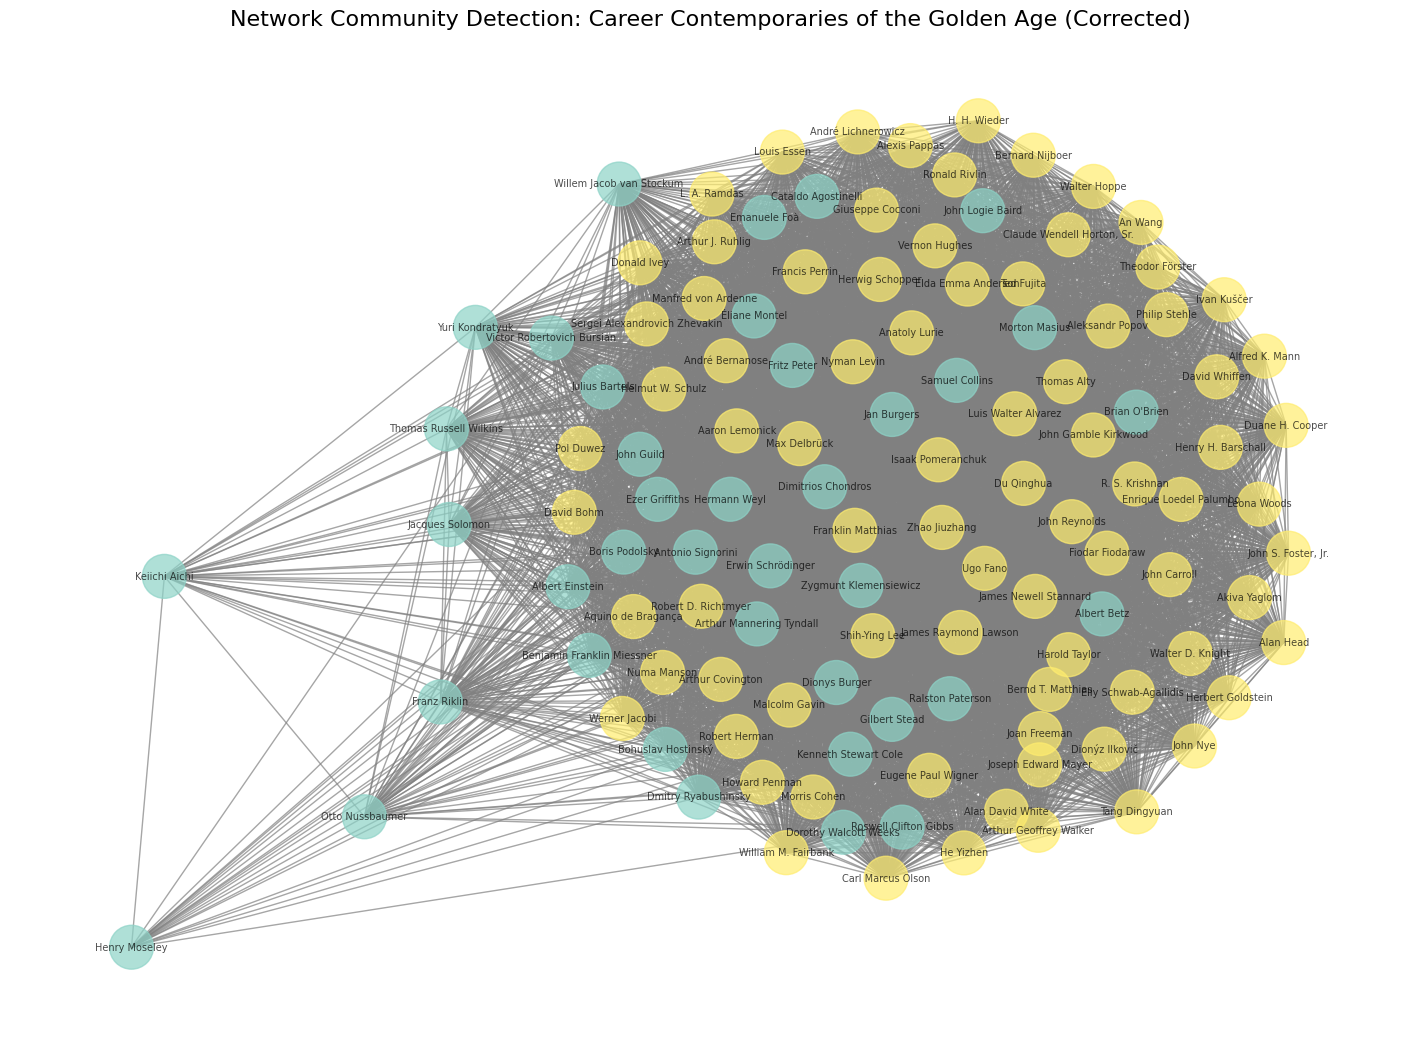

In [ ]:
from networkx.algorithms import community

# Filter for the Golden Age cohort
career_contemporaries = df_cleaned[(df_cleaned['Birth_Year'] >= 1875) & (df_cleaned['Birth_Year'] <= 1925)].dropna(subset=['Birth_Year', 'Death_Year'])

# Sample for visualization clarity
subset_ga = career_contemporaries.sample(min(len(career_contemporaries), 120), random_state=42)

G_comm = nx.Graph()

# Add nodes
for _, row in subset_ga.iterrows():
    G_comm.add_node(row['Name'], year=row['Birth_Year'])

# Create edges if their lifespans overlapped significantly (at least 25 years)
for i in range(len(subset_ga)):
    for j in range(i + 1, len(subset_ga)):
        p1 = subset_ga.iloc[i]
        p2 = subset_ga.iloc[j]
        overlap_start = max(p1['Birth_Year'], p2['Birth_Year'])
        overlap_end = min(p1['Death_Year'], p2['Death_Year'])
        if (overlap_end - overlap_start) >= 25:
            G_comm.add_edge(p1['Name'], p2['Name'])

# Community Detection (Louvain Method)
# Note: In NetworkX, Louvain is available as louvain_communities in algorithms.community
communities = community.louvain_communities(G_comm, seed=42)

# Map colors to communities
node_to_comm = {}
for i, comm_set in enumerate(communities):
    for node in comm_set:
        node_to_comm[node] = i

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_comm, k=0.2, iterations=50)

# Draw nodes
colors = [node_to_comm[node] for node in G_comm.nodes()]
nx.draw(G_comm, pos, node_color=colors, with_labels=True,
        cmap=plt.cm.Set3, node_size=1000, font_size=7,
        edge_color='gray', alpha=0.7)

plt.title('Network Community Detection: Career Contemporaries of the Golden Age (Corrected)', fontsize=16)
plt.show()